In [17]:
import pandas as pd
import matplotlib.pyplot as plt

df_companies = pd.read_csv("data/moved_project_sql_result_01.csv")
df_neighborhoods = pd.read_csv("data/moved_project_sql_result_04.csv")

In [18]:
print("=== project_sql_result_01.csv ===")
print(df_companies.head())
print(df_companies.info())
print(df_companies.describe())

print("\n=== project_sql_result_04.csv ===")
print(df_neighborhoods.head())
print(df_neighborhoods.info())
print(df_neighborhoods.describe())

=== project_sql_result_01.csv ===
                      company_name  trips_amount
0                        Flash Cab         19558
1        Taxi Affiliation Services         11422
2                 Medallion Leasin         10367
3                       Yellow Cab          9888
4  Taxi Affiliation Service Yellow          9299
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64 entries, 0 to 63
Data columns (total 2 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   company_name  64 non-null     object
 1   trips_amount  64 non-null     int64 
dtypes: int64(1), object(1)
memory usage: 1.1+ KB
None
       trips_amount
count     64.000000
mean    2145.484375
std     3812.310186
min        2.000000
25%       20.750000
50%      178.500000
75%     2106.500000
max    19558.000000

=== project_sql_result_04.csv ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Stree

In [19]:
top10_neighborhoods = df_neighborhoods.sort_values('average_trips', ascending=False).head(10)
print("\n=== Top 10 bairros de destino ===")
print(top10_neighborhoods)



=== Top 10 bairros de destino ===
  dropoff_location_name  average_trips
0                  Loop   10727.466667
1           River North    9523.666667
2         Streeterville    6664.666667
3             West Loop    5163.666667
4                O'Hare    2546.900000
5             Lake View    2420.966667
6            Grant Park    2068.533333
7         Museum Campus    1510.000000
8            Gold Coast    1364.233333
9    Sheffield & DePaul    1259.766667


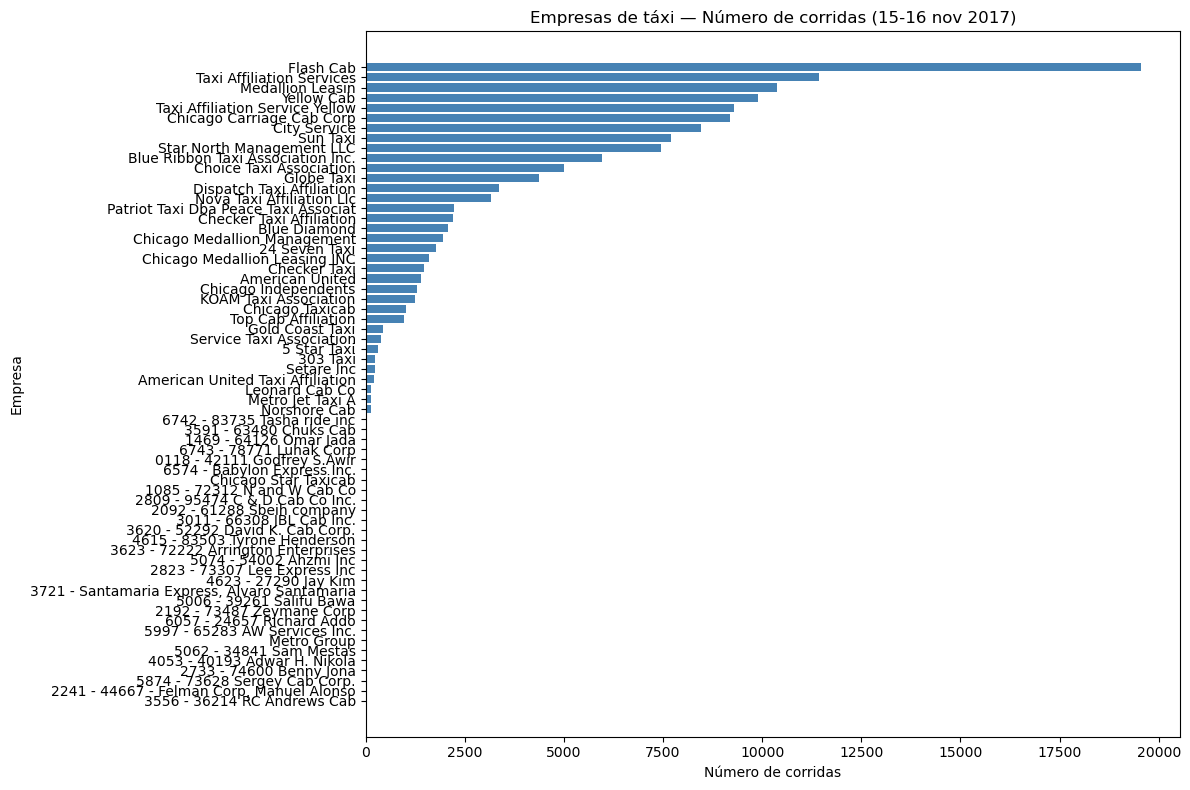

In [20]:
plt.figure(figsize=(12, 8))
plt.barh(df_companies['company_name'], df_companies['trips_amount'], color='steelblue')
plt.xlabel('Número de corridas')
plt.ylabel('Empresa')
plt.title('Empresas de táxi — Número de corridas (15-16 nov 2017)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


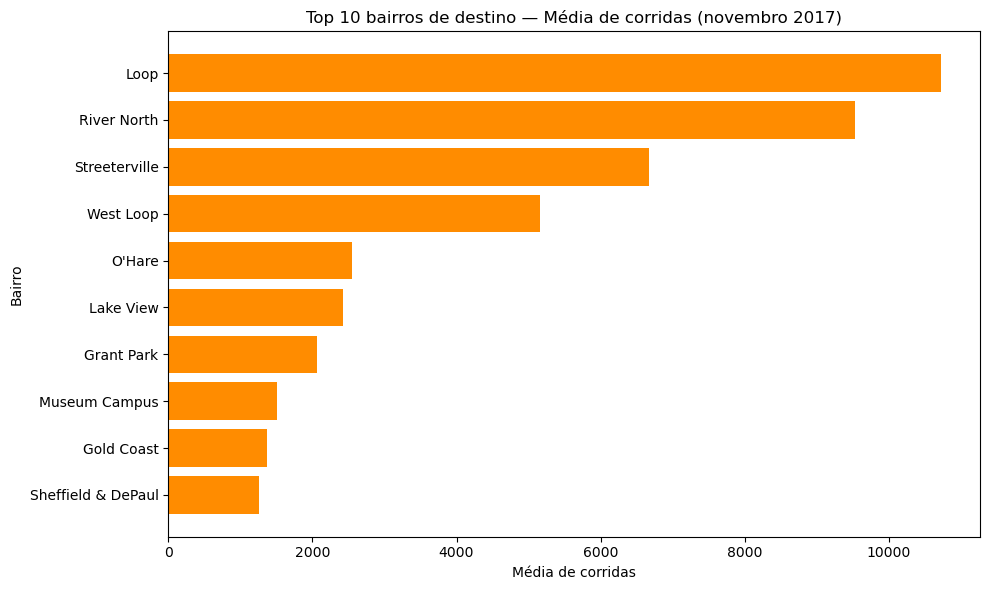

In [21]:
plt.figure(figsize=(10, 6))
plt.barh(top10_neighborhoods['dropoff_location_name'],
         top10_neighborhoods['average_trips'],
         color='darkorange')
plt.xlabel('Média de corridas')
plt.ylabel('Bairro')
plt.title('Top 10 bairros de destino — Média de corridas (novembro 2017)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

Número de corridas
Os dados mostram que as corridas estão concentradas em determinados bairros. Os 10 principais destinos possuem uma média de corridas significativamente maior, o que indica áreas de alta demanda, possivelmente regiões centrais ou comerciais.

Média de corridas
A concentração de corridas tanto por empresa quanto por localização sugere um padrão de mercado onde poucos atores dominam e a demanda está fortemente centralizada. Isso pode ajudar a Zuber a definir estratégias de entrada, focando em regiões de alta demanda e avaliando a concorrência direta.

In [22]:
import pandas as pd
from scipy import stats

#  1. Importar os dados 
df = pd.read_csv('data/moved_project_sql_result_07.csv')

#  2. Separar os grupos 
bad_weather  = df[df['weather_conditions'] == 'Bad']['duration_seconds']
good_weather = df[df['weather_conditions'] == 'Good']['duration_seconds']

print(f"Corridas com mau tempo:  {len(bad_weather)}")   # 180
print(f"Corridas com bom tempo:  {len(good_weather)}")  # 888

print(f"\nMédia mau tempo:  {bad_weather.mean():.2f} segundos")
print(f"Média bom tempo:  {good_weather.mean():.2f} segundos")

# 3. Teste de hipótese

alfa = 0.05

statistic, p_value = stats.ttest_ind(bad_weather, good_weather, equal_var=False)

print(f"\nEstatística t: {statistic:.4f}")
print(f"p-valor:       {p_value:.4f}")
print(f"Alfa:          {alfa}")

if p_value < alfa:
    print("\nResultado: REJEITA a hipótese nula.")
    print("A duração média das corridas É diferente com mau tempo nos sábados.")
else:
    print("\nResultado: NÃO rejeita a hipótese nula.")
    print("Não há evidências suficientes de que o clima afeta a duração.")

Corridas com mau tempo:  180
Corridas com bom tempo:  888

Média mau tempo:  2427.21 segundos
Média bom tempo:  1999.68 segundos

Estatística t: 7.1860
p-valor:       0.0000
Alfa:          0.05

Resultado: REJEITA a hipótese nula.
A duração média das corridas É diferente com mau tempo nos sábados.


Hipótese nula (H₀):
A duração média das corridas do Loop para O'Hare nos sábados não muda com o clima — ou seja, a média com mau tempo é igual à média com bom tempo.
Hipótese alternativa (H₁):
A duração média das corridas do Loop para O'Hare nos sábados é diferente quando o clima é ruim (chuva ou tempestade).

Critério utilizado — Teste t de Welch (ttest_ind com equal_var=False):
Escolhemos este teste pelos seguintes motivos:

Dois grupos independentes: as corridas com mau tempo (180) e bom tempo (888) são amostras separadas e independentes entre si
Variâncias desconhecidas e possivelmente diferentes: como os grupos têm tamanhos muito distintos (180 vs 888), não podemos assumir variâncias iguais — o teste de Welch é mais robusto nesse caso do que o teste t clássico
Variável contínua: duration_seconds é uma variável numérica contínua, adequada para o teste t
Nível de significância alfa = 0.05: padrão amplamente utilizado em análises estatísticas, significa que aceitamos 5% de chance de rejeitar H₀ incorretamente (erro tipo I)

Interpretação: se o p-valor retornado for menor que 0.05, rejeitamos H₀ e concluímos que o clima chuvoso/tempestuoso impacta significativamente a duração das corridas nos sábados entre o Loop e O'Hare.